# Prac 9


In [1]:
import cv2
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from time import perf_counter
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [2]:
def solve_poisson_seidel(div, boundary, max_iter=2000, tol=1e-4):
    rows, cols = div.shape
    f = boundary.copy().astype(np.float64)
    mask = (boundary == 0)

    for iteration in range(max_iter):
        f_old = f.copy()
        for i in range(1, rows-1):
            for j in range(1, cols-1):
                if mask[i, j]:
                    f[i, j] = (f[i-1, j] + f[i+1, j] +
                               f[i, j-1] + f[i, j+1] - div[i, j]) / 4.0

        error = np.max(np.abs(f - f_old))
        if error < tol:
            break

    return f

In [3]:
def solve_poisson_scipy(div, boundary):
    rows, cols = div.shape
    n = rows * cols

    def idx(i, j):
        return i * cols + j

    data, row_ids, col_ids = [], [], []
    b = np.zeros(n)

    for i in range(rows):
        for j in range(cols):
            k = idx(i, j)
            if i == 0 or i == rows-1 or j == 0 or j == cols-1:

                data.append(1.0)
                row_ids.append(k)
                col_ids.append(k)
                b[k] = boundary[i, j]
            else:

                data += [-1.0, -1.0, 4.0, -1.0, -1.0]
                row_ids += [k, k, k, k, k]
                col_ids += [idx(i-1,j), idx(i,j-1), k, idx(i,j+1), idx(i+1,j)]
                b[k] = -div[i, j]

    A = sp.csr_matrix((data, (row_ids, col_ids)), shape=(n, n))
    x = spla.spsolve(A, b)
    return x.reshape(rows, cols)

In [4]:
def compute_divergence(img_channel):
    gx = np.gradient(img_channel.astype(np.float64), axis=1)
    gy = np.gradient(img_channel.astype(np.float64), axis=0)
    div = np.gradient(gx, axis=1) + np.gradient(gy, axis=0)
    return div

In [5]:
def restore_image(img, method='scipy'):
    result = np.zeros_like(img, dtype=np.float64)

    for c in range(img.shape[2]):
        channel = img[:, :, c].astype(np.float64)
        div = compute_divergence(channel)
        boundary = channel.copy()
        boundary[1:-1, 1:-1] = 0

        if method == 'seidel':
            result[:, :, c] = solve_poisson_seidel(div, boundary)
        else:
            result[:, :, c] = solve_poisson_scipy(div, boundary)

    return np.clip(result, 0, 255).astype(np.uint8)

In [7]:
def test_image(img_path, sizes):
    img_orig = cv2.imread(img_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

    times_seidel = []
    times_scipy = []

    for size in sizes:
        img = cv2.resize(img_orig, (size, size))


        t0 = perf_counter()
        result_seidel = restore_image(img, method='seidel')
        t1 = perf_counter()
        times_seidel.append(t1 - t0)


        t0 = perf_counter()
        result_scipy = restore_image(img, method='scipy')
        t1 = perf_counter()
        times_scipy.append(t1 - t0)

        print(f'Size {size}x{size}: Seidel={times_seidel[-1]:.2f}s, Scipy={times_scipy[-1]:.2f}s')

    return times_seidel, times_scipy, result_seidel, result_scipy, img

sizes = [32, 64, 128]
times_seidel, times_scipy, res_seidel, res_scipy, img_test = test_image('/content/9_2.jpg', sizes)

Size 32x32: Seidel=4.59s, Scipy=0.03s
Size 64x64: Seidel=38.67s, Scipy=0.08s
Size 128x128: Seidel=138.10s, Scipy=0.43s


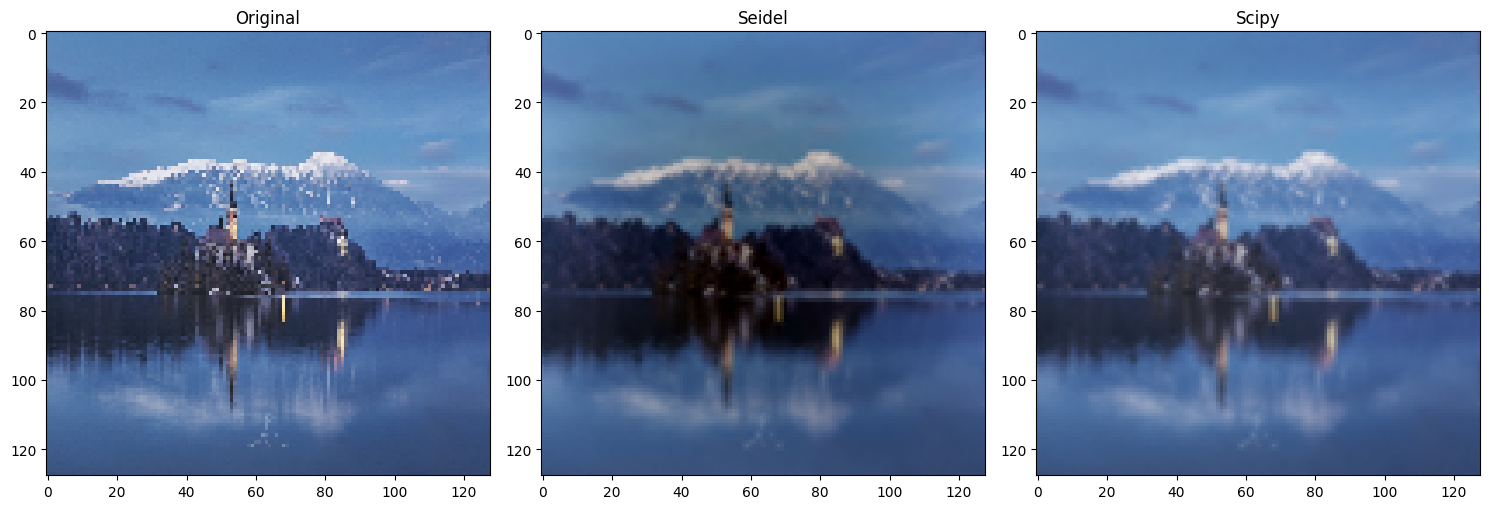

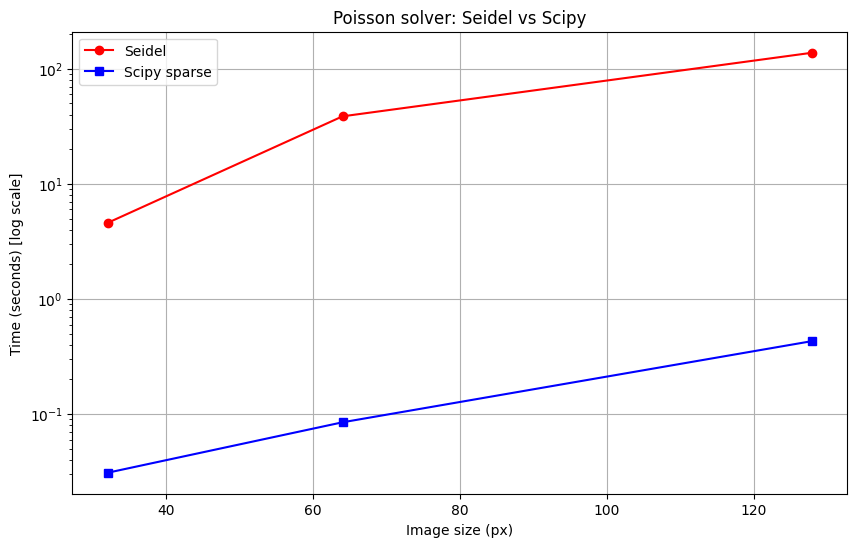

Size 32x32: Seidel=4.592s | Scipy=0.031s | Speedup=148.5x
Size 64x64: Seidel=38.675s | Scipy=0.085s | Speedup=455.9x
Size 128x128: Seidel=138.102s | Scipy=0.431s | Speedup=320.6x


In [8]:

plt.subplot(131), plt.imshow(img_test), plt.title('Original')
plt.subplot(132), plt.imshow(res_seidel), plt.title('Seidel')
plt.subplot(133), plt.imshow(res_scipy), plt.title('Scipy')
plt.tight_layout()
plt.show()


sizes = [32, 64, 128]
plt.figure(figsize=(10, 6))
plt.semilogy(sizes, times_seidel, 'o-', label='Seidel', color='red')
plt.semilogy(sizes, times_scipy, 's-', label='Scipy sparse', color='blue')
plt.grid(True)
plt.xlabel('Image size (px)')
plt.ylabel('Time (seconds) [log scale]')
plt.title('Poisson solver: Seidel vs Scipy')
plt.legend()
plt.show()

for s, ts, tc in zip(sizes, times_seidel, times_scipy):
    print(f'Size {s}x{s}: Seidel={ts:.3f}s | Scipy={tc:.3f}s | Speedup={ts/tc:.1f}x')

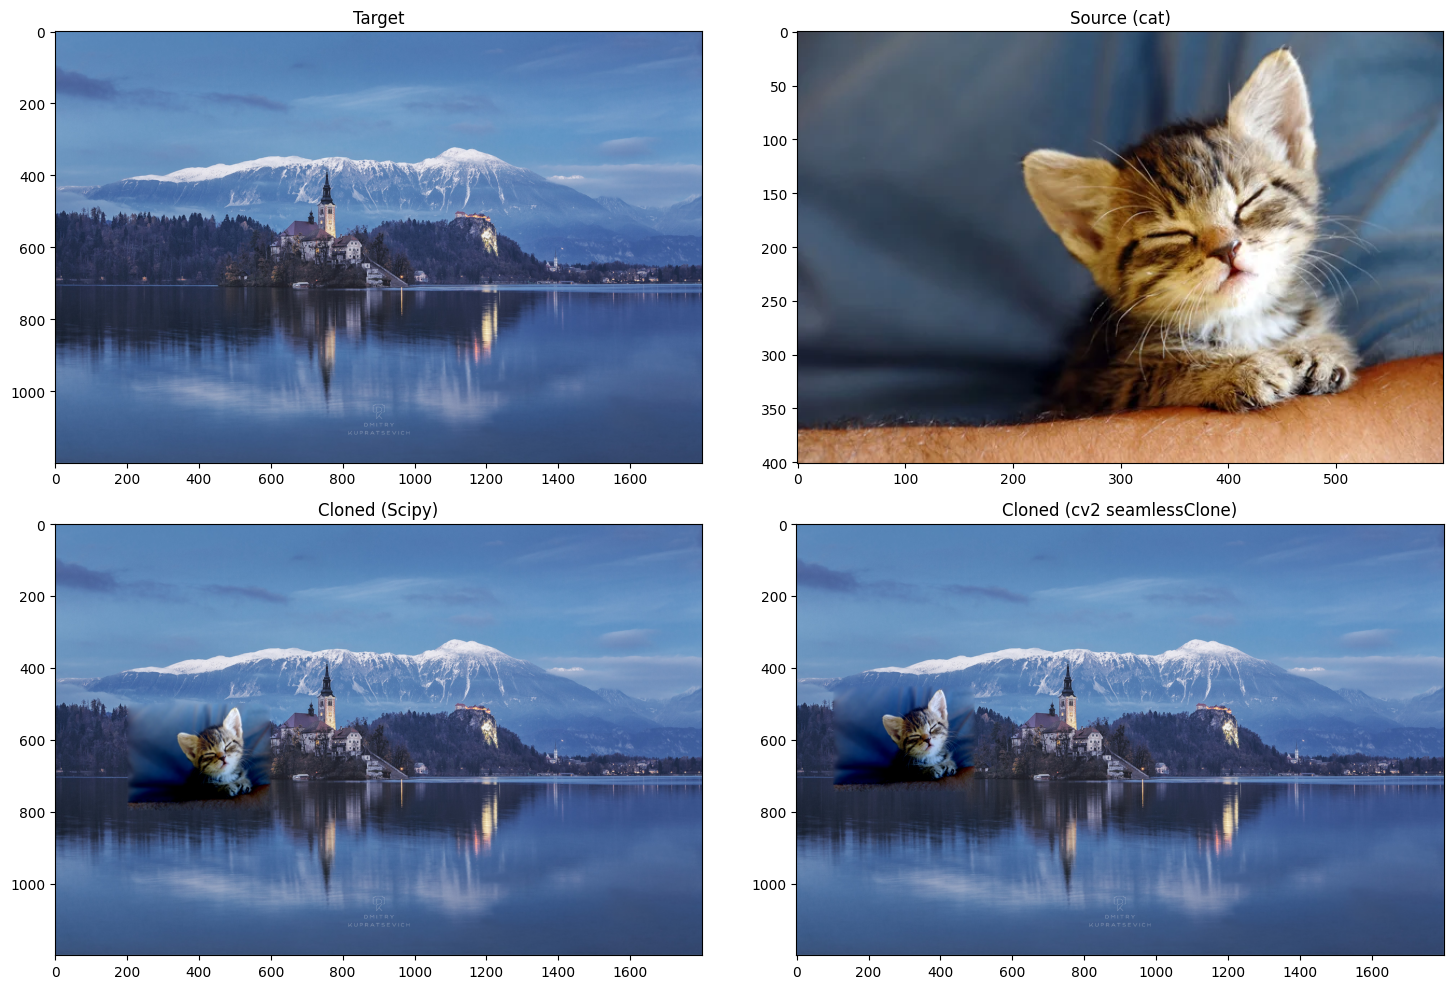

In [9]:
def seamless_clone(target, source, mask_region):
    result = target.copy().astype(np.float64)
    y1, y2, x1, x2 = mask_region

    for c in range(3):
        src_patch = source[:, :, c].astype(np.float64)
        div = compute_divergence(src_patch)
        boundary = target[y1:y2, x1:x2, c].astype(np.float64)
        boundary[1:-1, 1:-1] = 0

        solved = solve_poisson_scipy(div, boundary)
        result[y1:y2, x1:x2, c] = solved

    return np.clip(result, 0, 255).astype(np.uint8)


target = cv2.cvtColor(cv2.imread('/content/9_2.jpg'), cv2.COLOR_BGR2RGB)
source = cv2.cvtColor(cv2.imread('/content/9_6.jpg'), cv2.COLOR_BGR2RGB)


source_small = cv2.resize(
    cv2.cvtColor(source, cv2.COLOR_RGB2BGR), (400, 300))
target_bgr = cv2.cvtColor(target, cv2.COLOR_RGB2BGR)


mask_white = np.ones(source_small.shape[:2], dtype=np.uint8) * 255


center = (300, 600)


result_cv2 = cv2.seamlessClone(source_small, target_bgr, mask_white, center, cv2.NORMAL_CLONE)
result_rgb = cv2.cvtColor(result_cv2, cv2.COLOR_BGR2RGB)


source_small_rgb = cv2.cvtColor(source_small, cv2.COLOR_BGR2RGB)
h, w = source_small_rgb.shape[:2]
y_start = 500
x_start = 200


target_h, target_w = target.shape[:2]
y_end = min(y_start + h, target_h)
x_end = min(x_start + w, target_w)


src_h = y_end - y_start
src_w = x_end - x_start
source_cropped = source_small_rgb[:src_h, :src_w]

mask_region = (y_start, y_end, x_start, x_end)
cloned_scipy = seamless_clone(target, source_cropped, mask_region)


plt.subplot(221), plt.imshow(target), plt.title('Target')
plt.subplot(222), plt.imshow(source), plt.title('Source (cat)')
plt.subplot(223), plt.imshow(cloned_scipy), plt.title('Cloned (Scipy)')
plt.subplot(224), plt.imshow(result_rgb), plt.title('Cloned (cv2 seamlessClone)')
plt.tight_layout()
plt.show()